<a href="https://colab.research.google.com/github/sstanishk/tanishk-codeboosters-2026/blob/main/Day3/Day3miniproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
API_KEY = '34bf3577badd62038def839c765915e6'

BASE_URL = 'https://api.openweathermap.org/data/2.5/weather'

CITIES = [
    'Mumbai',
    'Bangalore',
    'Chennai',
    'Hyderabad',
    'Kolkata',
    'Pune',
    'Jaipur'
]

print(f'API configured for {len(CITIES)} cities')
print(f'BASE_URL = {BASE_URL}')
print(f'CITIES = {CITIES}')

API configured for 7 cities
BASE_URL = https://api.openweathermap.org/data/2.5/weather
CITIES = ['Mumbai', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Pune', 'Jaipur']


In [37]:
import requests

API_KEY = 'f93e5d4a1dc43dd0f13a34d059136b16'

BASE_URL = 'https://api.openweathermap.org/data/2.5/weather'

CITIES = [
    'Mumbai',
    'Bangalore',
    'Chennai',
    'Hyderabad',
    'Kolkata',
    'Pune',
    'Jaipur',
    'Coimbatore'
]


# Function to fetch weather data
def fetch_weather(city, API_KEY):

    """
    Fetch current weather data for a given city.
    Returns weather details dictionary or None on failure.
    """

    params = {
        'q': city,
        'appid': API_KEY,
        'units': 'metric'
    }

    try:

        response = requests.get(
            BASE_URL,
            params=params,
            timeout=10
        )

        if response.status_code == 200:

            data = response.json()

            return {
                'city': data['name'],
                'temperature': data['main']['temp'],
                'description': data['weather'][0]['description'],
                'icon': data['weather'][0]['icon'],
                'humidity': data['main']['humidity'],
                'wind_speed': data['wind']['speed'],
                'pressure': data['main']['pressure'],
                'visibility': data.get('visibility', 0),
                'sunrise': data['sys']['sunrise'],
                'sunset': data['sys']['sunset']
            }

        else:

            print(f"Error fetching weather data for {city}")
            print(f"Status code: {response.status_code}")

            return None

    except requests.exceptions.RequestException as e:

        print(f"Request failed: {e}")

        return None


# Call API for all cities
print("Calling Weather API...\n")

weather_records = []

for city in CITIES:

    print(f"Fetching weather for {city}...", end=' ')

    record = fetch_weather(city, API_KEY)

    if record:

        weather_records.append(record)

        print(
            f"{record['temperature']}°C, "
            f"{record['description']}"
        )

    else:

        print("Failed")

print("\nWeather Records:\n")

for record in weather_records:
    print(record)

Calling Weather API...

Fetching weather for Mumbai... 33.99°C, haze
Fetching weather for Bangalore... 29.44°C, scattered clouds
Fetching weather for Chennai... 35.86°C, few clouds
Fetching weather for Hyderabad... 31.23°C, broken clouds
Fetching weather for Kolkata... 31.97°C, haze
Fetching weather for Pune... 36.34°C, overcast clouds
Fetching weather for Jaipur... 42.62°C, haze
Fetching weather for Coimbatore... 33.88°C, scattered clouds

Weather Records:

{'city': 'Mumbai', 'temperature': 33.99, 'description': 'haze', 'icon': '50d', 'humidity': 59, 'wind_speed': 6.17, 'pressure': 1009, 'visibility': 7000, 'sunrise': 1779841877, 'sunset': 1779889230}
{'city': 'Bengaluru', 'temperature': 29.44, 'description': 'scattered clouds', 'icon': '03d', 'humidity': 56, 'wind_speed': 4.63, 'pressure': 1009, 'visibility': 8000, 'sunrise': 1779841358, 'sunset': 1779887466}
{'city': 'Chennai', 'temperature': 35.86, 'description': 'few clouds', 'icon': '02d', 'humidity': 53, 'wind_speed': 5.14, 'pre

In [40]:
import pandas as pd
weather_df=pd.DataFrame(weather_records)
print('Weather DataFrame created:')
print(weather_df.to_string(index=False))
print(weather_df.shape)
print(f'Missing Values:',{weather_df.isnull().sum().sum()})
print(f'\nData types:')
print(weather_df.dtypes)

Weather DataFrame created:
      city  temperature      description icon  humidity  wind_speed  pressure  visibility    sunrise     sunset
    Mumbai        33.99             haze  50d        59        6.17      1009        7000 1779841877 1779889230
 Bengaluru        29.44 scattered clouds  03d        56        4.63      1009        8000 1779841358 1779887466
   Chennai        35.86       few clouds  02d        53        5.14      1005        6000 1779840705 1779886835
 Hyderabad        31.23    broken clouds  04d        51        8.75      1008        6000 1779840700 1779887706
   Kolkata        31.97             haze  50d        62        4.12      1001        5000 1779837762 1779885894
      Pune        36.34  overcast clouds  04d        27        3.76      1008       10000 1779841688 1779888936
    Jaipur        42.62             haze  50d        15        5.14      1001        5000 1779840263 1779889419
Coimbatore        33.88 scattered clouds  03d        52        4.12      1008

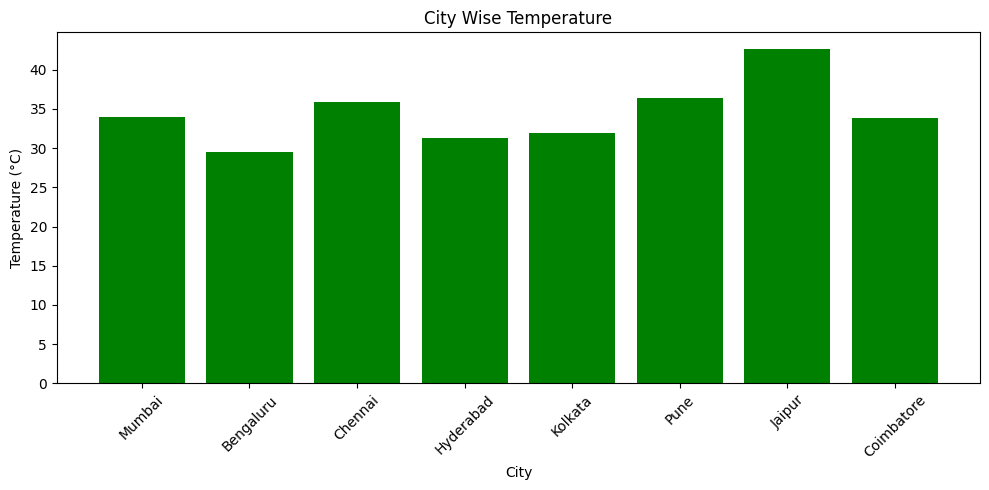

In [44]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))

plt.bar(
    weather_df['city'],
    weather_df['temperature'],
    color='green'
)

plt.title('City Wise Temperature')

plt.xlabel('City')

plt.ylabel('Temperature (°C)')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()